In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import nltk
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
# Relative Path Configuration
BASE_DIR = os.getcwd()

# Define output directory
DATA_DIR = os.path.join(BASE_DIR, '..', 'Database', 'Cleaned_Datasets')
os.makedirs(DATA_DIR, exist_ok=True)


#Define Model directory
MODEL_DIR = os.path.join(BASE_DIR, '..', 'Models')
os.makedirs(MODEL_DIR, exist_ok=True)

In [3]:
REVIEW_DATA_PATH = os.path.join(DATA_DIR, 'Review_Cleaned.csv')

# Load the cleaned review dataset
df = pd.read_csv(REVIEW_DATA_PATH)

In [4]:
df.head()

,review_id,book_id,user_id,review_text,ratings,review_date,source,author,book_name,cleaned_text,cleaned_tokens,lemmatized_tokens
0,1,B0033UV8HI,A3HHXRELK8BHQG,Jace Rankin may be short but hes nothing to me...,3,2010-09-02,Amazon,Unknown,Unknown,jace rankin may be short but hes nothing to me...,jace rankin may short hes nothing mess man hau...,"['jace', 'rankin', 'may', 'be', 'short', 'but'..."
1,2,B002HJV4DE,A2RGNZ0TRF578I,Great short read I didnt want to put it down s...,5,2013-10-08,Amazon,Unknown,Unknown,great short read i didnt want to put it down s...,great short didnt want put one sitting sex sce...,"['great', 'short', 'read', 'i', 'didnt', 'want..."
2,3,B002ZG96I4,A3S0H2HV6U1I7F,Ill start by saying this is the first of four ...,3,2014-04-11,Amazon,Unknown,Unknown,ill start by saying this is the first of four ...,ill start saying first four books wasnt expect...,"['ill', 'start', 'by', 'saying', 'this', 'is',..."
3,4,B002QHWOEU,AC4OQW3GZ919J,Aggie is Angela Lansbury who carries pocketboo...,3,2014-07-05,Amazon,Unknown,Unknown,aggie is angela lansbury who carries pocketboo...,aggie angela lansbury carries pocketbooks inst...,"['aggie', 'is', 'angela', 'lansbury', 'who', '..."
4,5,B001A06VJ8,A3C9V987IQHOQD,I did not expect this type of book to be in li...,4,2012-12-31,Amazon,Unknown,Unknown,i did not expect this type of book to be in li...,expect type library pleased find price right,"['i', 'did', 'not', 'expect', 'this', 'type', ..."


In [5]:
df.isnull().sum()

review_id            0
book_id              0
user_id              0
review_text          0
ratings              0
review_date          0
source               0
author               0
book_name            0
cleaned_text         0
cleaned_tokens       2
lemmatized_tokens    0
dtype: int64

In [6]:
# Drop rows with missing review_text
df.dropna(subset=['cleaned_tokens'], inplace=True)


In [7]:
# Drop rows where 'lemmatized_tokens' is null or empty
df = df[df['lemmatized_tokens'].notnull()]

In [8]:
# Use 'cleaned_text' or 'lemmatized_tokens' joined as string
df['tokens'] = df['lemmatized_tokens'].apply(eval).apply(lambda tokens: ' '.join(tokens))

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),         # unigrams + bigrams
    max_features=5000,          # limit vocabulary size
    min_df=5,                   # ignore very rare words
    max_df=0.9,                 # ignore very common words
)

X_tfidf = vectorizer.fit_transform(df['tokens'])

# Feature analysis
print("TF-IDF Matrix Shape:", X_tfidf.shape)
print("Sparsity:", 100.0 * (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])), "% non-zero entries")


TF-IDF Matrix Shape: (74907, 5000)
Sparsity: 3.06293564019384 % non-zero entries


pip install gensim nltk

In [9]:
# Prepare tokens
tokenized_reviews = df['lemmatized_tokens'].apply(eval)

In [10]:
w2v_model_path = os.path.join(MODEL_DIR, 'word2vec.model')

if os.path.exists(w2v_model_path):
    print("Loading existing Word2Vec model...")
    model = Word2Vec.load(w2v_model_path)
else:
    print("Training Word2Vec model...")
    model = Word2Vec(
        sentences=tokenized_reviews,
        vector_size=100,
        window=5,
        min_count=2,
        workers=4,
        sg=1
    )
    model.save(w2v_model_path)

Training Word2Vec model...


In [11]:
# Function to convert a review into a vector (average of word vectors)
def get_vector(tokens, model):
    valid_vecs = [model.wv[word] for word in tokens if word in model.wv]
    if valid_vecs:
        return np.mean(valid_vecs, axis=0)
    else:
        return np.zeros(model.vector_size)

# Show progress bar while generating review embeddings
tqdm.pandas(desc="Generating Word2Vec embeddings")
df['w2v_vector'] = tokenized_reviews.progress_apply(lambda x: get_vector(x, model))

# Stack into a feature matrix
X_w2v = np.stack(df['w2v_vector'].values)

print("Word2Vec Feature Matrix Shape:", X_w2v.shape)

Generating Word2Vec embeddings: 100%|██████████████████████████████████████████| 74907/74907 [01:04<00:00, 1159.30it/s]


Word2Vec Feature Matrix Shape: (74907, 100)


pip install vaderSentiment

In [12]:
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment scoring
tqdm.pandas(desc="Sentiment Labeling")
df['vader_score'] = df['review_text'].progress_apply(lambda text: analyzer.polarity_scores(str(text))['compound'])

# Assign sentiment labels
def get_sentiment_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['vader_score'].apply(get_sentiment_label)

# View distribution
print(df['sentiment'].value_counts())

Sentiment Labeling: 100%|███████████████████████████████████████████████████████| 74907/74907 [09:55<00:00, 125.79it/s]

positive    56107
negative    16286
neutral      2514
Name: sentiment, dtype: int64


In [17]:
df.head()

,review_id,book_id,user_id,review_text,ratings,review_date,source,author,book_name,cleaned_text,cleaned_tokens,lemmatized_tokens,tokens,w2v_vector,vader_score,sentiment
0,1,B0033UV8HI,A3HHXRELK8BHQG,Jace Rankin may be short but hes nothing to me...,3,2010-09-02,Amazon,Unknown,Unknown,jace rankin may be short but hes nothing to me...,jace rankin may short hes nothing mess man hau...,"['jace', 'rankin', 'may', 'be', 'short', 'but'...",jace rankin may be short but he nothing to mes...,"[-0.048696145, 0.20041396, -0.053822726, -0.05...",0.9661,positive
1,2,B002HJV4DE,A2RGNZ0TRF578I,Great short read I didnt want to put it down s...,5,2013-10-08,Amazon,Unknown,Unknown,great short read i didnt want to put it down s...,great short didnt want put one sitting sex sce...,"['great', 'short', 'read', 'i', 'didnt', 'want...",great short read i didnt want to put it down s...,"[0.0039983774, 0.14723115, -0.118756965, -0.12...",0.9600,positive
2,3,B002ZG96I4,A3S0H2HV6U1I7F,Ill start by saying this is the first of four ...,3,2014-04-11,Amazon,Unknown,Unknown,ill start by saying this is the first of four ...,ill start saying first four books wasnt expect...,"['ill', 'start', 'by', 'saying', 'this', 'is',...",ill start by saying this is the first of four ...,"[-0.031597666, 0.17707181, -0.06081005, -0.023...",0.7650,positive
3,4,B002QHWOEU,AC4OQW3GZ919J,Aggie is Angela Lansbury who carries pocketboo...,3,2014-07-05,Amazon,Unknown,Unknown,aggie is angela lansbury who carries pocketboo...,aggie angela lansbury carries pocketbooks inst...,"['aggie', 'is', 'angela', 'lansbury', 'who', '...",aggie is angela lansbury who carry pocketbook ...,"[-0.008472442, 0.2208083, -0.079912156, 0.0340...",-0.1280,negative
4,5,B001A06VJ8,A3C9V987IQHOQD,I did not expect this type of book to be in li...,4,2012-12-31,Amazon,Unknown,Unknown,i did not expect this type of book to be in li...,expect type library pleased find price right,"['i', 'did', 'not', 'expect', 'this', 'type', ...",i did not expect this type of book to be in li...,"[-0.04064076, 0.14156152, -0.02016523, -0.0259...",0.4404,positive


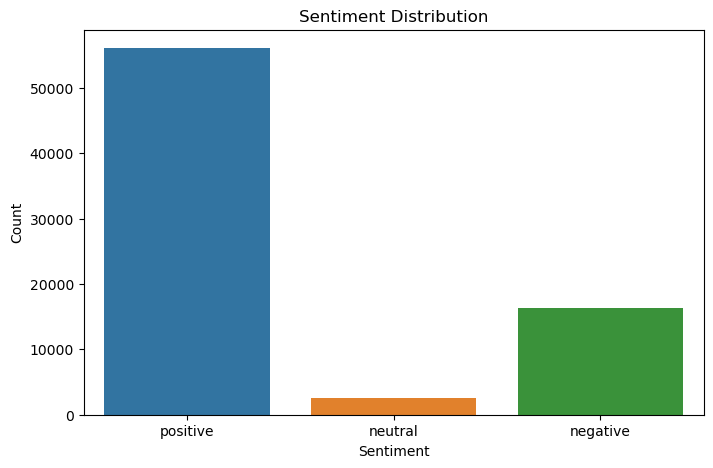

In [18]:
# Plot sentiment distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', order=['positive', 'neutral', 'negative'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

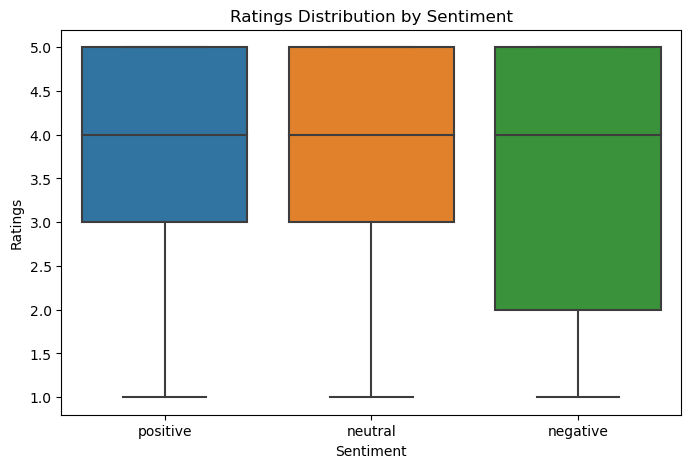

In [19]:
# Plot rating distribution grouped by sentiment
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sentiment', y='ratings', order=['positive', 'neutral', 'negative'])
plt.title("Ratings Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Ratings")
plt.show()

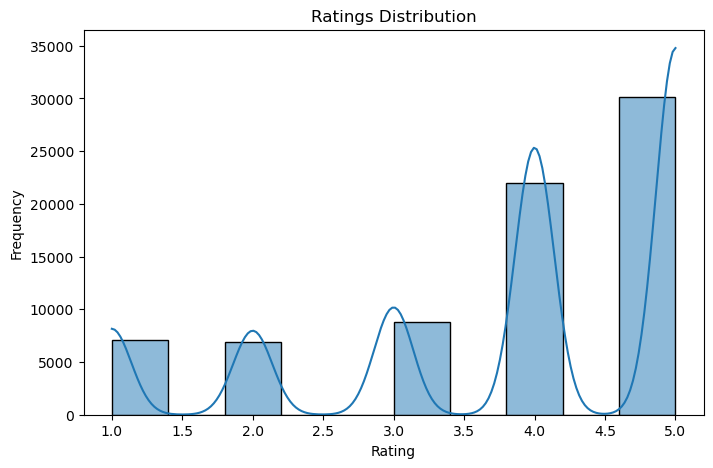

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df['ratings'], bins=10, kde=True)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Text(0.5, 1.0, 'TF-IDF Feature Matrix (Sample)')

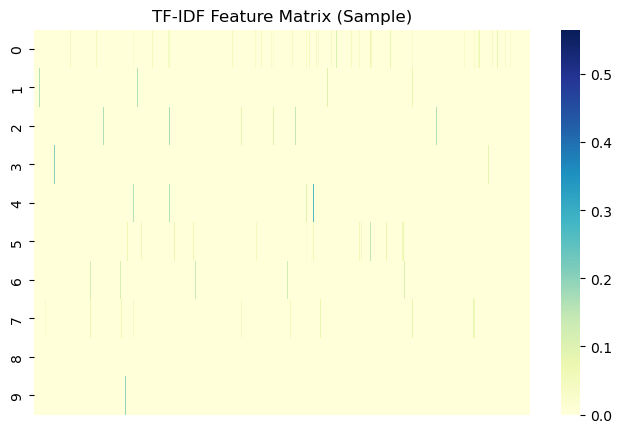

In [25]:
plt.figure(figsize=(8, 5))
sample = X_tfidf[:10].toarray()
sns.heatmap(sample, cmap='YlGnBu', xticklabels=False)
plt.title("TF-IDF Feature Matrix (Sample)")

Text(0.5, 1.0, 'Word2Vec Embeddings Heatmap')

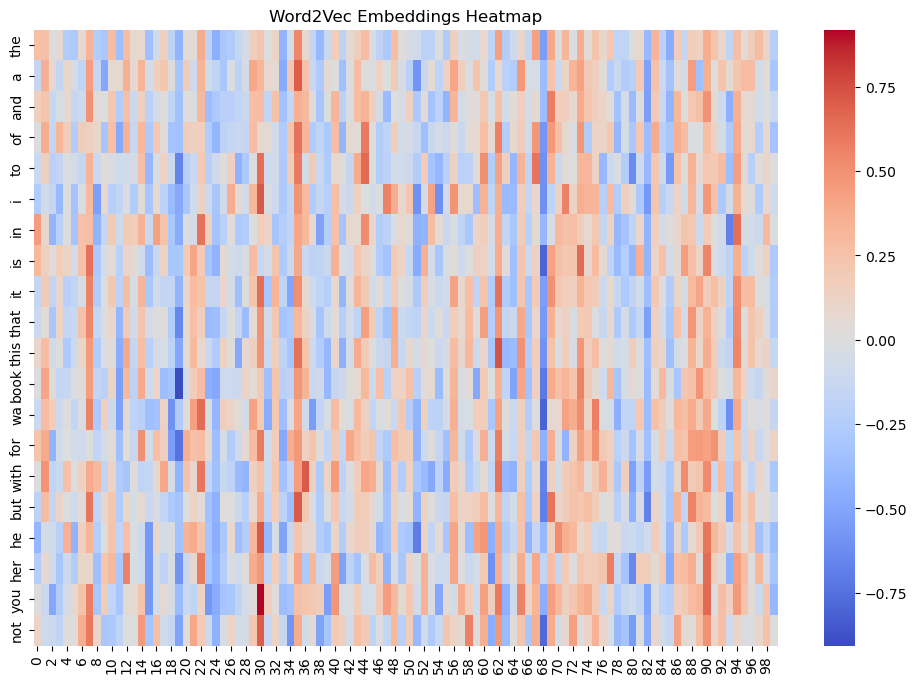

In [28]:
plt.figure(figsize=(12, 8))
sample_words = list(model.wv.key_to_index)[:20]
embeddings = np.array([model.wv[word] for word in sample_words])
sns.heatmap(embeddings, cmap='coolwarm', yticklabels=sample_words)
plt.title("Word2Vec Embeddings Heatmap")

In [16]:
# Save processed dataset
output_path = os.path.join(DATA_DIR, "processed_reviews_with_embeddings_and_sentiment.csv")
df.to_csv(output_path, index=False)
print(f"Processed dataset saved to {output_path}")

Processed dataset saved to C:\Users\HP\Desktop\Bookify\Notebooks\..\Database\Cleaned_Datasets\processed_reviews_with_embeddings_and_sentiment.csv
